Assignment two 2/1/2026 

Breanna Robinson

In [47]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import math 

Problem 1: The Falling Sphere (Data vs. Theory)

Importing files 

In [48]:
filename = 'drop_data.csv'

np.loadtxt('drop_data.csv', delimiter=',', skiprows=1)   
#Skiprow is telling the code to not include the first row of the document, whuch is usally the description row 




array([[ 0.        ,  1.14161705],
       [ 0.33333333,  5.65205891],
       [ 0.66666667,  6.91363926],
       [ 1.        ,  7.73071926],
       [ 1.33333333, 11.41660405],
       [ 1.66666667, 13.39190253],
       [ 2.        , 17.12317422],
       [ 2.33333333, 18.00122161],
       [ 2.66666667, 18.54507366],
       [ 3.        , 20.67204574],
       [ 3.33333333, 22.21381616],
       [ 3.66666667, 24.95987249],
       [ 4.        , 24.56374749],
       [ 4.33333333, 27.47036478],
       [ 4.66666667, 29.56418015],
       [ 5.        , 26.25439926],
       [ 5.33333333, 30.74089891],
       [ 5.66666667, 30.03904637],
       [ 6.        , 31.64380562],
       [ 6.33333333, 33.06110307],
       [ 6.66666667, 32.93614965],
       [ 7.        , 35.6273346 ],
       [ 7.33333333, 31.40580343],
       [ 7.66666667, 33.97014178],
       [ 8.        , 37.57818736]])

Define Two Functions

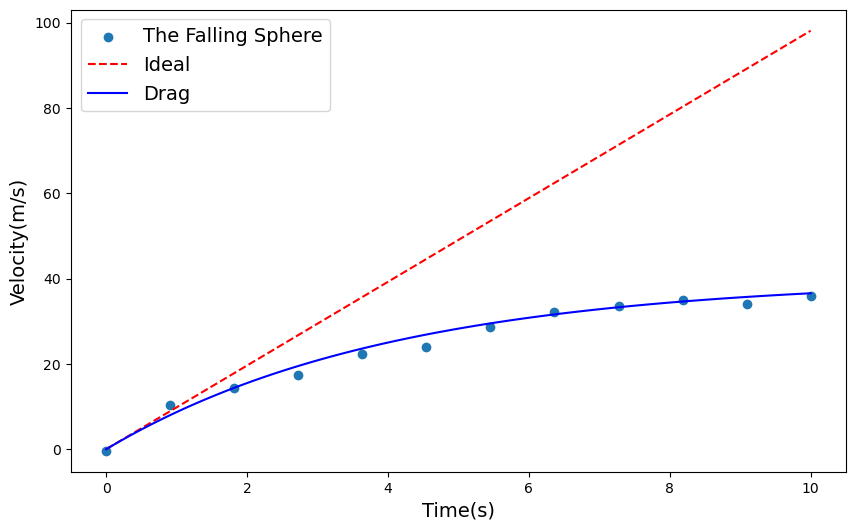

In [49]:
g = 9.81    #m/s^2
v_term = 40.0   #m/s 
#velocity without air resistance
def model_a_ideal(t):
    return g * t 
#velocity with air resistance 
def model_b_drag(t):
    return v_term * (1-np.exp(-g * t / v_term))

#Python, Real. “Defining Your Own Python Function – Real Python.” Realpython.com, realpython.com/defining-your-own-python-function/.

t_plot = np.linspace(0,10,100) 
t_data = np.linspace(0,10,12)
v_data = model_b_drag(t_data) + np.random.normal(0,1.5,12)  

plt.figure(figsize=(10,6))
plt.scatter(t_data, v_data, label = 'The Falling Sphere') 
plt.plot(t_plot, model_a_ideal(t_plot), 'r--', label = 'Ideal') 
plt.plot(t_plot, model_b_drag(t_plot), 'b-', label = 'Drag') 

plt.xlabel('Time(s)', fontsize=14)
plt.ylabel('Velocity(m/s)', fontsize=14) 
plt.legend(fontsize=14)
plt.show()

#The Ideal model stops being a good repersentation around 1 second, this is shown by the devation in a linear form as the drag continues into a curve.

#Jimoh, Abdulsomad Abiola. “A Comprehensive Guide to Training a Simple Linear Regression Model in Julia.” DEV Community, 19 Dec. 2024, dev.to/engineerlambda/a-comprehensive-guide-to-training-a-simple-linear-regression-model-in-julia-5675. Accessed 2 Feb. 2026.


Problem 2: Parameter Sweeping (Finding the Drag)

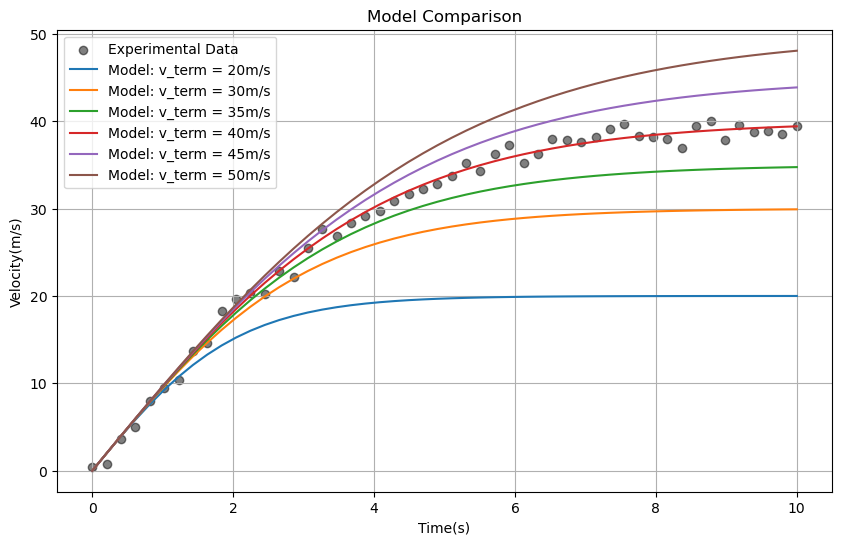

In [50]:
def plot_model_comparison(t_data, v_data, v_term_guess):
    v_model = v_term_guess * np.tanh((g * t_data) / v_term_guess) 
    plt.plot(t_data, v_model, label = f"Model: v_term = {v_term_guess}m/s")

t_data = np.linspace(0, 10, 50) 
v_data = 40 * np.tanh((g * t_data) / 40) + np.random.normal(0, 1, 50)

plt.figure(figsize=(10, 6))
plt.scatter(t_data, v_data, color='black', label='Experimental Data', alpha=0.5)   

v_guesses = [20, 30, 35, 40, 45, 50] 
for guess in v_guesses: 
    plot_model_comparison(t_data, v_data, guess)

plt.xlabel('Time(s)')
plt.ylabel('Velocity(m/s)')
plt.title('Model Comparison')
plt.legend()
plt.grid(True)
plt.show()

#The value that fits the data best is 40 m/s

Problem 3: Hookes Law & Estimating fits 

In [51]:
filename = 'spring_data.csv'

np.loadtxt('spring_data.csv', delimiter=',', skiprows=1)   



array([[0.1       , 0.03630129],
       [0.2       , 0.09030086],
       [0.3       , 0.13111254],
       [0.4       , 0.16512215],
       [0.5       , 0.19352901],
       [0.6       , 0.22900467],
       [0.7       , 0.29305891],
       [0.8       , 0.32542225],
       [0.9       , 0.35153585],
       [1.        , 0.40179937],
       [1.1       , 0.42648887],
       [1.2       , 0.47062424],
       [1.3       , 0.50227212],
       [1.4       , 0.53476172],
       [1.5       , 0.59585908]])

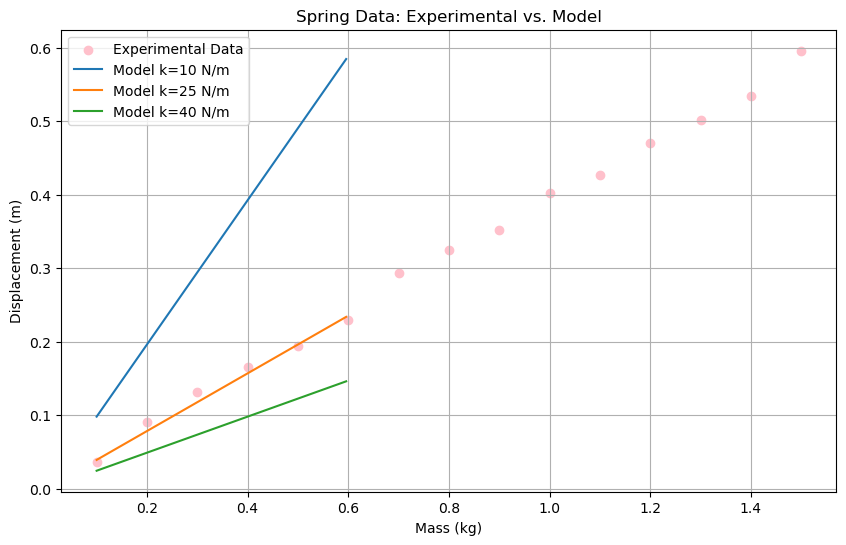

In [52]:
df = pd.read_csv('spring_data.csv') 
exp_mass = df['mass'] 
exp_disp = df['displacement'] 

k_values = [10, 25, 40] 

plt.figure(figsize=(10,6)) 
plt.scatter(exp_mass, exp_disp, color='pink', label='Experimental Data') 

mass_range = np.linspace(min(exp_mass), max(exp_disp), 100)
for k in k_values:
    model_disp = (mass_range * g) / k 
    plt.plot(mass_range, model_disp, label=f'Model k={k} N/m') 

plt.xlabel('Mass (kg)')
plt.ylabel('Displacement (m)')
plt.title('Spring Data: Experimental vs. Model')
plt.legend()
plt.grid(True) 
plt.show()


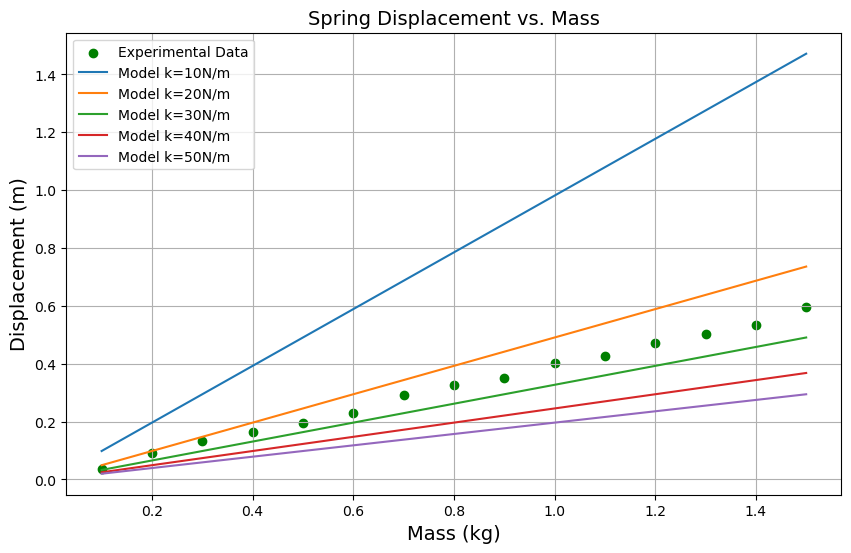

In [ ]:
# ...existing code...
# Option A — from the pandas DataFrame you already have:
#m = df['mass'].values
#displacement = df['displacement'].values


data = np.loadtxt('spring_data.csv', delimiter=',', skiprows=1)
m = data[:, 0]                      #kilograms
displacement = data[:, 1]               #m




def spring_model(m, k):
    return((m * g)/k)

def calculat_residuals(x_experimental, x_model):
    return x_experimental - x_model 

def calculate_mse(x_experimental, x_model): 
    residuals = x_experimental - x_model 
    mse = np.mean(residuals**2) 
    return mse

k_values = [10, 20, 30, 40, 50]
plt.figure(figsize=(10,6)) 
plt.scatter(m, displacement, color = 'green', label = 'Experimental Data')

for k in k_values:
    plt.plot(m, spring_model(m,k), label = f'Model k={k}N/m') 
    plt.xlabel("Mass (kg)", fontsize = 14) 
    plt.ylabel("Displacement (m)", fontsize = 14) 
    plt.title("Spring Displacement vs. Mass", fontsize = 14)  
    plt.legend()
plt.grid(True) 
plt.show()

    